# Geometric Brownian motion

Geometric Brownian motion (GBM) is the standard model for strictly positive, compounding quantities — asset prices, populations, anything that grows *multiplicatively*. Its log grows as a drifting random walk, so the level is log-normal and never goes negative.

::: {.callout-note}
## The model

$$dS_t = \mu\,S_t\,dt + \sigma\,S_t\,dW_t$$

Returns are proportional to the current level: `drift` (`mu`) sets the exponential growth rate and `volatility` (`sigma`) the multiplicative noise. This is the process behind Black-Scholes option pricing.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import GeometricBrownianMotionGenerator

## 1. Basic stock price simulation

A standard GBM with 5% annual drift and 20% volatility, starting at 100.

In [ ]:
basic_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.2,
    "initial_value": 100.0,
    "seed": 42,
}

basic_gen = GeometricBrownianMotionGenerator(engine="polars", **basic_params)
basic_df = basic_gen.generate(n_series=1)

print(f"Generated {len(basic_df)} observations (starting at {basic_params['initial_value']})")
print(f"Statistics: Mean={basic_df['y'].mean():.4f}, Min={basic_df['y'].min():.4f}, Max={basic_df['y'].max():.4f}")
basic_df.head(10)

Generated 200 observations (starting at 100.0)
Statistics: Mean=26728.5201, Min=66.9310, Max=132041.2507


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,77.855257
"""0""",2000-01-03 00:00:00,66.931005
"""0""",2000-01-04 00:00:00,83.485543
"""0""",2000-01-05 00:00:00,92.09352
"""0""",2000-01-06 00:00:00,85.875252
"""0""",2000-01-07 00:00:00,77.473016
"""0""",2000-01-08 00:00:00,90.038957
"""0""",2000-01-09 00:00:00,86.666449


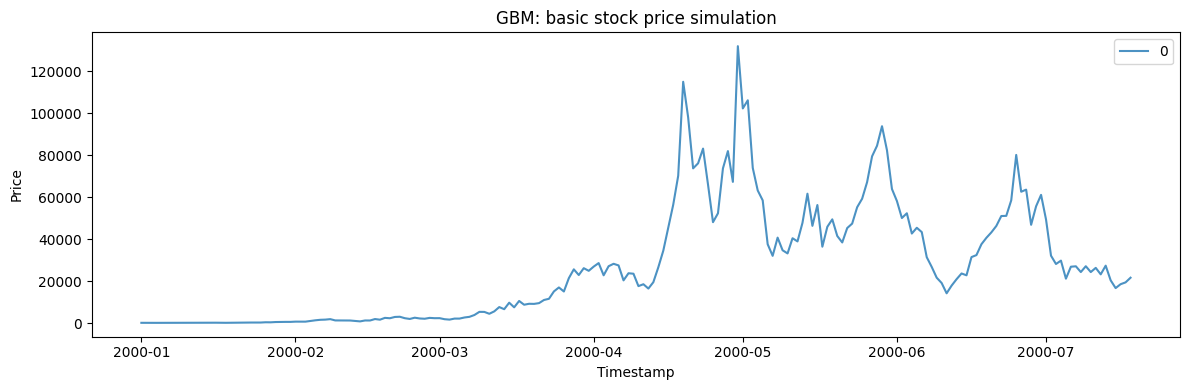

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in basic_df["unique_id"].unique().to_list():
    series = basic_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("GBM: basic stock price simulation")
ax.legend()
plt.tight_layout()
plt.show()

## 2. High growth stock (high drift)

A 15% drift rate with 30% volatility simulates a high-growth asset.

In [ ]:
high_growth_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.15,
    "sigma": 0.3,
    "initial_value": 50.0,
    "seed": 42,
}

high_growth_gen = GeometricBrownianMotionGenerator(engine="polars", **high_growth_params)
high_growth_df = high_growth_gen.generate(n_series=1)

print(f"Generated {len(high_growth_df)} observations with high growth rate")
print(f"Statistics: Mean={high_growth_df['y'].mean():.4f}, Min={high_growth_df['y'].min():.4f}, Max={high_growth_df['y'].max():.4f}")
high_growth_df.head(10)

Generated 200 observations with high growth rate
Statistics: Mean=4185320814.3454, Min=30.8693, Max=43769024468.9006


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,50.0
"""0""",2000-01-02 00:00:00,36.472001
"""0""",2000-01-03 00:00:00,30.86927
"""0""",2000-01-04 00:00:00,45.662525
"""0""",2000-01-05 00:00:00,56.175157
"""0""",2000-01-06 00:00:00,53.710647
"""0""",2000-01-07 00:00:00,48.86993
"""0""",2000-01-08 00:00:00,65.015869
"""0""",2000-01-09 00:00:00,65.194035


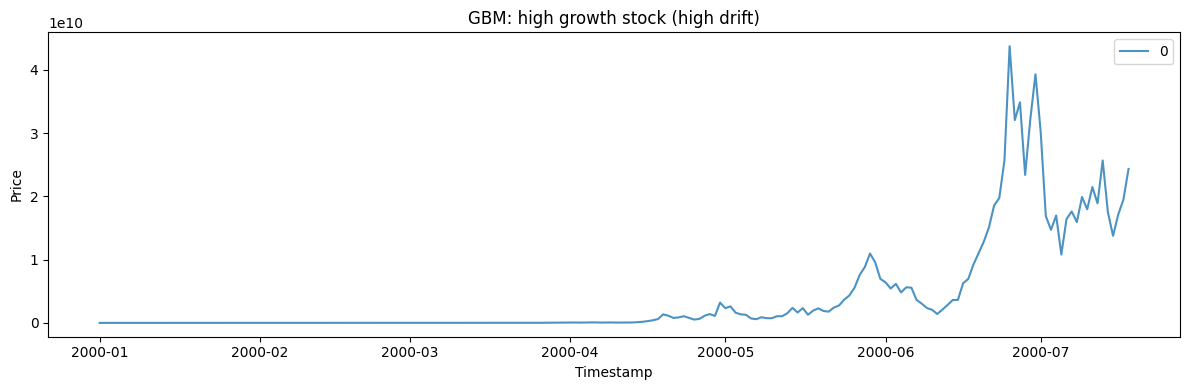

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_growth_df["unique_id"].unique().to_list():
    series = high_growth_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("GBM: high growth stock (high drift)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Declining stock (negative drift)

A negative drift (-5%) simulates a declining asset.

In [ ]:
declining_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": -0.05,
    "sigma": 0.2,
    "initial_value": 100.0,
    "seed": 42,
}

declining_gen = GeometricBrownianMotionGenerator(engine="polars", **declining_params)
declining_df = declining_gen.generate(n_series=1)

print(f"Generated {len(declining_df)} observations with negative drift")
print(f"Statistics: Mean={declining_df['y'].mean():.4f}, Min={declining_df['y'].min():.4f}, Max={declining_df['y'].max():.4f}")
declining_df.head(10)

Generated 200 observations with negative drift
Statistics: Mean=9.7741, Min=0.0000, Max=100.0000


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,70.44635
"""0""",2000-01-03 00:00:00,54.798472
"""0""",2000-01-04 00:00:00,61.847612
"""0""",2000-01-05 00:00:00,61.732133
"""0""",2000-01-06 00:00:00,52.085973
"""0""",2000-01-07 00:00:00,42.518093
"""0""",2000-01-08 00:00:00,44.712023
"""0""",2000-01-09 00:00:00,38.941746


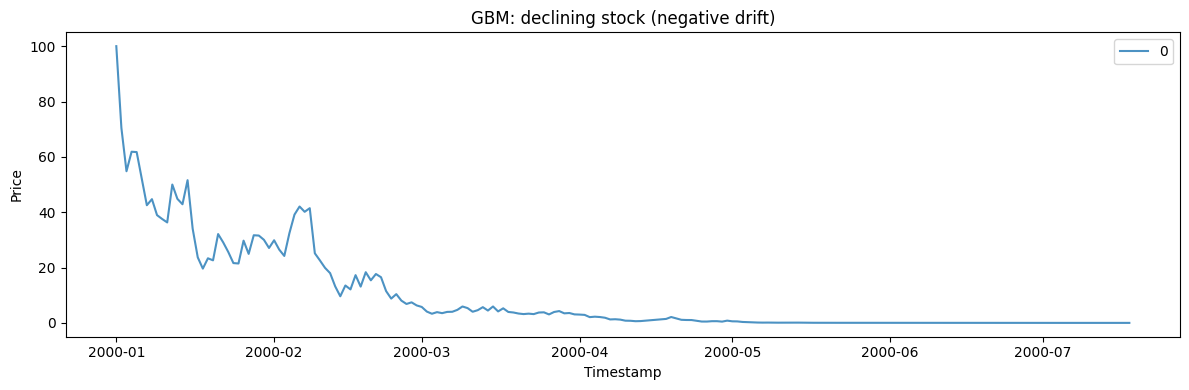

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in declining_df["unique_id"].unique().to_list():
    series = declining_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("GBM: declining stock (negative drift)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. High volatility stock

A 50% volatility produces extreme price swings.

In [ ]:
high_vol_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.5,
    "initial_value": 100.0,
    "seed": 42,
}

high_vol_gen = GeometricBrownianMotionGenerator(engine="polars", **high_vol_params)
high_vol_df = high_vol_gen.generate(n_series=1)

print(f"Generated {len(high_vol_df)} observations with high volatility")
print(f"Statistics: Mean={high_vol_df['y'].mean():.4f}, Min={high_vol_df['y'].min():.4f}, Max={high_vol_df['y'].max():.4f}")
high_vol_df.head(10)

Generated 200 observations with high volatility
Statistics: Mean=50.6428, Min=0.0000, Max=494.4897


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,46.033679
"""0""",2000-01-03 00:00:00,27.150637
"""0""",2000-01-04 00:00:00,40.606511
"""0""",2000-01-05 00:00:00,44.667948
"""0""",2000-01-06 00:00:00,32.281165
"""0""",2000-01-07 00:00:00,21.478855
"""0""",2000-01-08 00:00:00,26.919497
"""0""",2000-01-09 00:00:00,21.060765


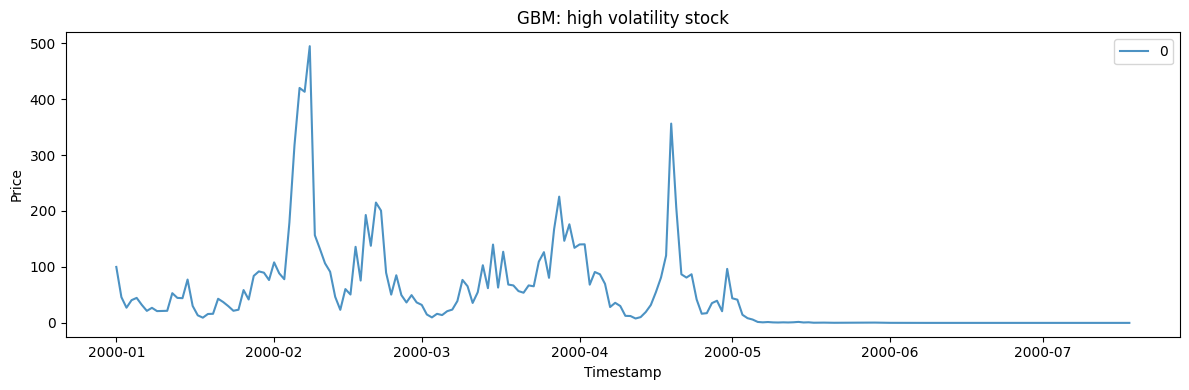

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in high_vol_df["unique_id"].unique().to_list():
    series = high_vol_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("GBM: high volatility stock")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Multiple stock price simulations

Generate 5 independent GBM paths in one call.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.2,
    "initial_value": 100.0,
    "seed": 42,
}

multi_gen = GeometricBrownianMotionGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=5)

print(f"Generated 5 stock price simulations with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Min={multi_df['y'].min():.4f}, Max={multi_df['y'].max():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 5 stock price simulations with 750 total observations
Overall Statistics: Mean=33529.5984, Min=39.7278, Max=1355600.3980


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,77.855257
"""0""",2000-01-03 00:00:00,66.931005
"""0""",2000-01-04 00:00:00,83.485543
"""0""",2000-01-05 00:00:00,92.09352
"""0""",2000-01-06 00:00:00,85.875252
"""0""",2000-01-07 00:00:00,77.473016
"""0""",2000-01-08 00:00:00,90.038957
"""0""",2000-01-09 00:00:00,86.666449


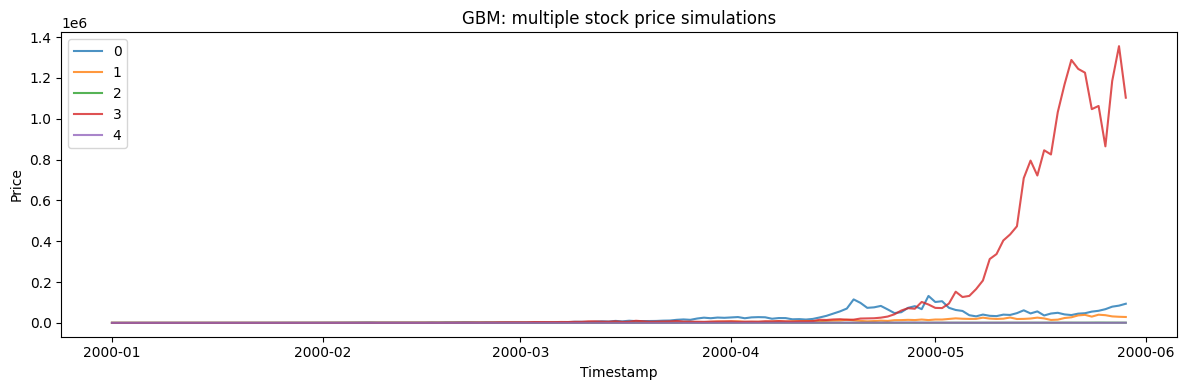

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("GBM: multiple stock price simulations")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Random walk](../statistical/random_walk) — the *additive* counterpart.
- [Jump diffusion](jump_diffusion) — GBM plus sudden jumps.

Drift and volatility parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::